# 09 · Irrigation

Compare rainfed maize with automatic irrigation across a management-depth and threshold grid at Gainesville in 1982.

## You will learn

- Use experiment controls to compare rainfed and automatic irrigation.
- Run nine depth and threshold combinations with nitrogen limitation removed.
- Compare grain yield and total irrigation in a table and inline heatmaps.

In [1]:
LESSON = "09_irrigation"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for tables and inline plots.

In [3]:
# Load tools for tables and inline plots.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Select the copied FileX, weather and soil in `runs/` for the same maize case as lesson 01.

In [4]:
# Select the copied stock inputs and show their relative paths.
inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
print("Inputs:", ", ".join(inputs[key].relative_to(HERE).as_posix()
                          for key in ("filex", "weather", "soil")))

Inputs: runs/UFGA8201.MZX, runs/UFGA8201.WTH, runs/SOIL.SOL


🌱 Crop idea  
Treatment 1 uses McCurdy 84aa (`IB0035`), planted on 26 February 1982 in Millhopper Fine Sand.
Its stock irrigation schedule includes 13 mm despite the RAINFED label, so we remove it for a rainfed comparison.

Check rainfed experiment data with water simulation on and nitrogen simulation off to focus on water limitation.

In [5]:
# Remove reported irrigation and check the rainfed controls.
rainfed_controls = {"water": "Y", "nitrogen": "N", "irrigation_management": "N"}
experiment = {"treatments": {1: {"irrigation": [], "controls": rainfed_controls}}}
sim = dl.Simulation(**inputs, treatment=1, management=experiment)
problems = sim.check(verbose=False)
print("Problems:", problems)

Problems: []


🐍 Python idea  
A dictionary pairs each control name with a value; `[]` means no reported irrigation events.
`**inputs` passes the copied paths as named arguments, and `Problems: []` means the checks found none.

Run rainfed and potential-production references and compare grain yield (`HWAM`, kg/ha) and total applied irrigation (`IRCM`, mm).

In [6]:
# Run the two references and display their yield and irrigation.
potential_experiment = {"treatments": {1: {
    "irrigation": [],
    "controls": {"water": "N", "nitrogen": "N", "irrigation_management": "N"},
}}}
reference_runs = dl.run_treatments(
    **inputs, treatments=[1], management=experiment,
    scenarios={"potential": {"management": potential_experiment}},
)
references = dl.to_dataframe(dl.combine_summaries(reference_runs))
references["Case"] = references["scenario"].replace({"base": "Rainfed", "potential": "Potential"})
references[["Case", "HWAM", "IRCM"]]

,Case,HWAM,IRCM
0,Rainfed,2010,0
1,Potential,11859,0


🌱 Crop idea  
Rainfed yield is 2,010 kg/ha versus 11,859 kg/ha with water and nitrogen simulation off, consistent with water limitation under these controls.
Automatic irrigation keeps water simulation on, so it need not reach that potential-production reference.

Build a 3 × 3 grid that refills to 100% of available water capacity using furrow irrigation (`IR001`) with efficiency 1.

In [7]:
# Build complete automatic-irrigation controls for nine combinations.
depths = [15, 30, 60]
thresholds = [30, 50, 70]
controls_grid = {}
for depth in depths:
    for threshold in thresholds:
        controls_grid[f"{depth}cm {threshold}%"] = {
            "water": "Y",
            "nitrogen": "N",
            "irrigation_management": "A",
            "auto_irrigation_depth": depth,
            "auto_irrigation_threshold": threshold,
            "auto_irrigation_refill": 100,
            "auto_irrigation_method": "IR001",
            "auto_irrigation_efficiency": 1,
        }
dl.to_dataframe([{
    "Setting": label,
    "Depth (cm)": controls["auto_irrigation_depth"],
    "Threshold (%)": controls["auto_irrigation_threshold"],
} for label, controls in controls_grid.items()])

,Setting,Depth (cm),Threshold (%)
0,15cm 30%,15,30
1,15cm 50%,15,50
2,15cm 70%,15,70
3,30cm 30%,30,30
4,30cm 50%,30,50
5,30cm 70%,30,70
6,60cm 30%,60,30
7,60cm 50%,60,50
8,60cm 70%,60,70


🌱 Crop idea  
Management depth is the soil depth used to decide when to irrigate, not the rooting depth.
Threshold is the percentage of plant-available water remaining within the management depth, measured between the lower limit and drained upper limit; refill 100% targets the drained upper limit. [DSSAT definitions](https://dssat.net/wp-content/uploads/2011/10/DSSAT-vol2.pdf)
Under `"A"`, DSSAT refills when soil water falls below the threshold; a higher threshold triggers irrigation while the soil is wetter.

🐍 Python idea  
The two loops pair every depth with every threshold.
Both values belong to `controls`, so each labelled sweep value contains that whole section, including water and nitrogen settings.

Run the nine automatic settings plus the rainfed base and show the grain yield and irrigation for all ten cases.

In [8]:
# Run the controls sweep and display the rainfed base and nine settings.
rows = dl.run_sweep(**inputs, treatments=[1], management=experiment,
                    factors={"controls": controls_grid})
comparison_rows = []
for row in rows:
    setting = controls_grid.get(row["controls"], {})
    comparison_rows.append({
        "Case": "Rainfed" if row["scenario"] == "base" else row["controls"],
        "Depth (cm)": setting.get("auto_irrigation_depth"),
        "Threshold (%)": setting.get("auto_irrigation_threshold"),
        "HWAM (kg/ha)": row["HWAM"],
        "IRCM (mm)": row["IRCM"],
    })
comparison = dl.to_dataframe(comparison_rows)
comparison

,Case,Depth (cm),Threshold (%),HWAM (kg/ha),IRCM (mm)
0,Rainfed,NaN,NaN,2010,0
1,15cm 30%,15.0,30.0,10649,161
2,15cm 50%,15.0,50.0,10937,198
3,15cm 70%,15.0,70.0,11859,289
4,30cm 30%,30.0,30.0,11016,173
5,30cm 50%,30.0,50.0,11691,194
6,30cm 70%,30.0,70.0,11859,265
7,60cm 30%,60.0,30.0,11428,169
8,60cm 50%,60.0,50.0,11854,231
9,60cm 70%,60.0,70.0,11859,275


Filter out the extra rainfed base and plot each automatic setting once in two heatmaps with values and units.

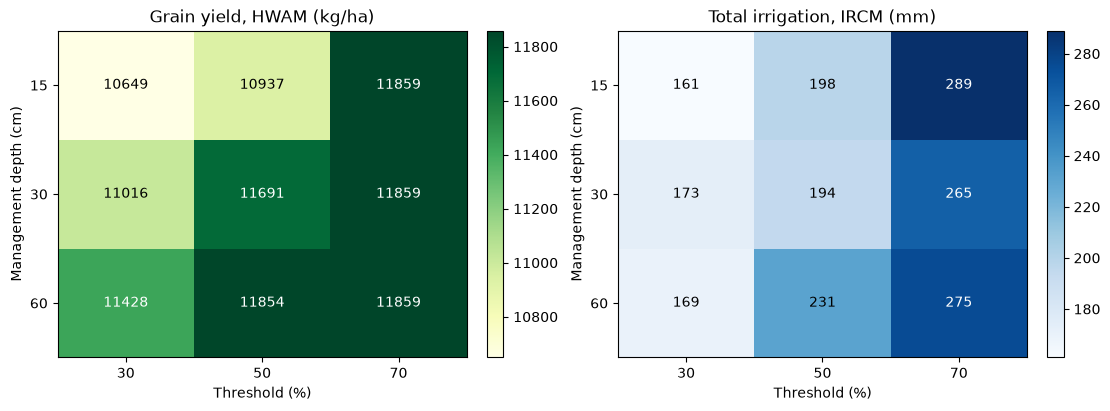

In [9]:
# Plot grain yield and total irrigation across the same nine settings.
grid = comparison.loc[comparison["Case"] != "Rainfed"].copy()
yield_map = grid.pivot(index="Depth (cm)", columns="Threshold (%)", values="HWAM (kg/ha)")
irrigation_map = grid.pivot(index="Depth (cm)", columns="Threshold (%)", values="IRCM (mm)")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, table, title, color in zip(
    axes, [yield_map, irrigation_map],
    ["Grain yield, HWAM (kg/ha)", "Total irrigation, IRCM (mm)"],
    ["YlGn", "Blues"],
):
    image = ax.imshow(table.to_numpy(), cmap=color, aspect="auto")
    ax.set_xticks(range(len(table.columns)), [f"{value:g}" for value in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{value:g}" for value in table.index])
    ax.set(xlabel="Threshold (%)", ylabel="Management depth (cm)", title=title)
    for i in range(len(table.index)):
        for j in range(len(table.columns)):
            value = table.iloc[i, j]
            ink = "white" if image.norm(value) > 0.55 else "black"
            ax.text(j, i, f"{value:.0f}", ha="center", va="center", color=ink)
    fig.colorbar(image, ax=ax)
plt.show()

🐍 Python idea  
`pivot` puts depths into rows and thresholds into columns.
Each colour scale belongs to its own metric; the numbers inside the cells give the actual kg/ha or mm.

🌱 Crop idea  
The identical 70% threshold yields may look surprising: all three match the 11,859 kg/ha potential reference, but use 265–289 mm of irrigation.
At each depth, a higher threshold increases yield and applied water here; changing depth does not give a consistent increase in water use.

Compare the nine settings with the rainfed and potential references to show yield gains and the remaining yield gap.

In [10]:
# Compare each automatic setting with the two reference yields.
rainfed_yield = references.loc[references["Case"] == "Rainfed", "HWAM"].iloc[0]
potential_yield = references.loc[references["Case"] == "Potential", "HWAM"].iloc[0]
yield_comparison = grid[["Case", "HWAM (kg/ha)", "IRCM (mm)"]].copy()
yield_comparison["Gain over rainfed (kg/ha)"] = yield_comparison["HWAM (kg/ha)"] - rainfed_yield
yield_comparison["Potential minus irrigated (kg/ha)"] = potential_yield - yield_comparison["HWAM (kg/ha)"]
yield_comparison

,Case,HWAM (kg/ha),IRCM (mm),Gain over rainfed (kg/ha),Potential minus irrigated (kg/ha)
1,15cm 30%,10649,161,8639,1210
2,15cm 50%,10937,198,8927,922
3,15cm 70%,11859,289,9849,0
4,30cm 30%,11016,173,9006,843
5,30cm 50%,11691,194,9681,168
6,30cm 70%,11859,265,9849,0
7,60cm 30%,11428,169,9418,431
8,60cm 50%,11854,231,9844,5
9,60cm 70%,11859,275,9849,0


## Your turn

Compare rainfed maize with one automatic setting at two irrigation efficiencies (1 means 100% of applied water reaches the soil; 0.5 means 50%).

Hint: edit `chosen_threshold` (try 70, from 0 to 100), then run this cell; depth stays at 30 cm.

In [11]:
# Rebuild the exercise and compare two efficiencies with rainfed maize.
chosen_threshold = 50
exercise_inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
exercise_experiment = {"treatments": {1: {
    "irrigation": [],
    "controls": {"water": "Y", "nitrogen": "N", "irrigation_management": "N"},
}}}
exercise_controls = {}
for efficiency in (1, 0.5):
    exercise_controls[f"eff {efficiency}"] = {
        "water": "Y",
        "nitrogen": "N",
        "irrigation_management": "A",
        "auto_irrigation_depth": 30,
        "auto_irrigation_threshold": chosen_threshold,
        "auto_irrigation_refill": 100,
        "auto_irrigation_method": "IR001",
        "auto_irrigation_efficiency": efficiency,
    }
exercise_rows = dl.run_sweep(**exercise_inputs, treatments=[1],
                             management=exercise_experiment,
                             factors={"controls": exercise_controls})
dl.to_dataframe([{
    "Case": "Rainfed" if row["scenario"] == "base" else row["controls"],
    "Threshold (%)": None if row["scenario"] == "base" else chosen_threshold,
    "Efficiency": exercise_controls.get(row["controls"], {}).get("auto_irrigation_efficiency"),
    "HWAM (kg/ha)": row["HWAM"],
    "IRCM (mm)": row["IRCM"],
} for row in exercise_rows])

,Case,Threshold (%),Efficiency,HWAM (kg/ha),IRCM (mm)
0,Rainfed,NaN,NaN,2010,0
1,eff 1,50.0,1.0,11691,194
2,eff 0.5,50.0,0.5,11559,344


## Recap

- `irrigation: []` removes reported events; controls `"N"` and `"A"` select rainfed and automatic irrigation.
- Management depth and threshold control when automatic irrigation refills soil water; `IRCM` reports total applied irrigation in mm.
- With nitrogen simulation off, compare `HWAM` in kg/ha against both rainfed and potential-production references.

Guide: [Management data](../../docs/guide/management.md) and [Experiment data](../../docs/guide/experiment.md).

Next: [10 · CO2, radiation and temperature](../10_climate_change/lesson.ipynb).